## ET Assignment 2

In [5]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

|Student | Study Hours | Attendance (%) | Assignment Score | Previous Exam | Final Score |
| --- | --- | --- | --- | --- | --- |
|S1 | 2 | 65 | 50 | 48 | 52 | 
|S2 | 3 | 70 | 55 | 52 | 57 | 
|S3 | 4 | 72 | ? | 58 | 61 | 
|S4 | 5 | 78 | 65 | ? | 67 | 
|S5 | 6 | 80 | 70 | 68 | 72 | 
|S6 | 7 | ? | 75 | 73 | 77 | 
|S7 | 8 | 88 | 80 | 79 | 82 | 
|S8 | ? | 90 | 85 | 84 | 87 | 
|S9 | 10 | 94 | 90 | 89 | 92 | 
|S10 | 11 | 96 | 92 | 94 | 95 |

In [17]:
data1 = {
    "Student": ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10"],
    "Study Hours": [2, 3, 4, 5, 6, 7, 8, np.nan, 10, 11],
    "Attendance": [65, 70, 72, 78, 80, np.nan, 88, 90, 94, 96],
    "Assignment Score": [50, 55, np.nan, 65, 70, 75, 80, 85, 90, 92],
    "Previous Exam": [48, 52, 58, np.nan, 68, 73, 79, 84, 89, 94],
    "Final Score": [52, 57, 61, 67, 72, 77, 82, 87, 92, 95]
}

df1 = pd.DataFrame(data1)
df1

,Student,Study Hours,Attendance,Assignment Score,Previous Exam,Final Score
0,S1,2.0,65.0,50.0,48.0,52
1,S2,3.0,70.0,55.0,52.0,57
2,S3,4.0,72.0,NaN,58.0,61
3,S4,5.0,78.0,65.0,NaN,67
4,S5,6.0,80.0,70.0,68.0,72
5,S6,7.0,NaN,75.0,73.0,77
6,S7,8.0,88.0,80.0,79.0,82
7,S8,NaN,90.0,85.0,84.0,87
8,S9,10.0,94.0,90.0,89.0,92
9,S10,11.0,96.0,92.0,94.0,95


In [9]:
student_ids = df1["Student"]
X1 = df1.drop(columns=["Student"])
X1

,Study Hours,Attendance,Assignment Score,Previous Exam,Final Score
0,2.0,65.0,50.0,48.0,52
1,3.0,70.0,55.0,52.0,57
2,4.0,72.0,NaN,58.0,61
3,5.0,78.0,65.0,NaN,67
4,6.0,80.0,70.0,68.0,72
5,7.0,NaN,75.0,73.0,77
6,8.0,88.0,80.0,79.0,82
7,NaN,90.0,85.0,84.0,87
8,10.0,94.0,90.0,89.0,92
9,11.0,96.0,92.0,94.0,95


1) Identify all missing values in the dataset and Why is KNN Imputation suitable for this
dataset? Apply KNN imputer.

In [10]:
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

In [11]:
knn_imputer = KNNImputer(
    n_neighbors=2,
    weights="uniform"
)

X1_imputed_scaled = knn_imputer.fit_transform(X1_scaled)

In [13]:
X1_imputed = scaler1.inverse_transform(X1_imputed_scaled)

df1_knn = pd.DataFrame(
    X1_imputed,
    columns=X1.columns
)

df1_knn.insert(0, "Student", student_ids)
df1_knn

,Student,Study Hours,Attendance,Assignment Score,Previous Exam,Final Score
0,S1,2.0,65.0,50.0,48.0,52.0
1,S2,3.0,70.0,55.0,52.0,57.0
2,S3,4.0,72.0,60.0,58.0,61.0
3,S4,5.0,78.0,65.0,63.0,67.0
4,S5,6.0,80.0,70.0,68.0,72.0
5,S6,7.0,84.0,75.0,73.0,77.0
6,S7,8.0,88.0,80.0,79.0,82.0
7,S8,9.0,90.0,85.0,84.0,87.0
8,S9,10.0,94.0,90.0,89.0,92.0
9,S10,11.0,96.0,92.0,94.0,95.0


2) Compare KNN with Mean/Median Imputation for each missing numerical value.

In [14]:
mean_values = X1.mean()
median_values = X1.median()

comparison = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values
})

missing_columns = {
    "Assignment Score": 2,
    "Previous Exam": 3,
    "Attendance": 5,
    "Study Hours": 7
}

comparison["KNN"] = np.nan

comparison.loc["Assignment Score", "KNN"] = df1_knn.loc[2, "Assignment Score"]
comparison.loc["Previous Exam", "KNN"] = df1_knn.loc[3, "Previous Exam"]
comparison.loc["Attendance", "KNN"] = df1_knn.loc[5, "Attendance"]
comparison.loc["Study Hours", "KNN"] = df1_knn.loc[7, "Study Hours"]

comparison

,Mean,Median,KNN
Study Hours,6.222222,6.0,9.0
Attendance,81.444444,80.0,84.0
Assignment Score,73.555556,75.0,60.0
Previous Exam,71.666667,73.0,63.0
Final Score,74.200000,74.5,NaN


| Employee | Experience (Years) | Training Hours | Projects Completed | Performance Score | Salary (₹000) |
| --- | --- | --- | --- | --- | --- |
|E1 | 1 | 20| 2 | 55 |28 |
|E2 | 2 | 25| 3 | 60 |32 |
|E3 | 3 | ? | 4 | 65 |36 |
|E4 | 4 | 35| ? | 70 |40 |
|E5 | 5 | 40| 6 | ?  |44 |
|E6 | ? | 45| 7 | 80 |48 |
|E7 | 7 | 50| 8 | 84 | ? |
|E8 | 8 | 55| 9 | 88 |58 |
|E9 | 9 | ? |10 | 92 |63 |
|E10|10 | 65| ? | 96 |68 |

3) Identify all missing values in the dataset. Why is simply replacing every missing value
with the mean potentially inappropriate?

there are 7 missing values:

| Employee | Attribute          |
| -------- | ------------------ |
| E3       | Training Hours     |
| E4       | Projects Completed |
| E5       | Performance Score  |
| E6       | Experience         |
| E7       | Salary             |
| E9       | Training Hours     |
| E10      | Projects Completed |


Replacing every missing value with the mean can be inappropriate because it ignores relationships between variables.


4) Apply Iterative Imputer.

In [16]:
import numpy as np
import pandas as pd

data2 = {
    "Employee": ["E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9", "E10"],
    "Experience": [1, 2, 3, 4, 5, np.nan, 7, 8, 9, 10],
    "Training Hours": [20, 25, np.nan, 35, 40, 45, 50, 55, np.nan, 65],
    "Projects Completed": [2, 3, 4, np.nan, 6, 7, 8, 9, 10, np.nan],
    "Performance Score": [55, 60, 65, 70, np.nan, 80, 84, 88, 92, 96],
    "Salary": [28, 32, 36, 40, 44, 48, np.nan, 58, 63, 68]
}

df2 = pd.DataFrame(data2)
df2

,Employee,Experience,Training Hours,Projects Completed,Performance Score,Salary
0,E1,1.0,20.0,2.0,55.0,28.0
1,E2,2.0,25.0,3.0,60.0,32.0
2,E3,3.0,NaN,4.0,65.0,36.0
3,E4,4.0,35.0,NaN,70.0,40.0
4,E5,5.0,40.0,6.0,NaN,44.0
5,E6,NaN,45.0,7.0,80.0,48.0
6,E7,7.0,50.0,8.0,84.0,NaN
7,E8,8.0,55.0,9.0,88.0,58.0
8,E9,9.0,NaN,10.0,92.0,63.0
9,E10,10.0,65.0,NaN,96.0,68.0


In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [19]:
employee_ids = df2["Employee"]

X2 = df2.drop(columns=["Employee"])

In [20]:
iterative_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

X2_imputed = iterative_imputer.fit_transform(X2)

In [22]:
df2_imputed = pd.DataFrame(
    X2_imputed,
    columns=X2.columns
)

df2_imputed.insert(0, "Employee", employee_ids)
df2_imputed

,Employee,Experience,Training Hours,Projects Completed,Performance Score,Salary
0,E1,1.000000,20.000000,2.000000,55.000000,28.000000
1,E2,2.000000,25.000000,3.000000,60.000000,32.000000
2,E3,3.000000,29.999764,4.000000,65.000000,36.000000
3,E4,4.000000,35.000000,4.999948,70.000000,40.000000
4,E5,5.000000,40.000000,6.000000,75.003339,44.000000
5,E6,5.999899,45.000000,7.000000,80.000000,48.000000
6,E7,7.000000,50.000000,8.000000,84.000000,53.000984
7,E8,8.000000,55.000000,9.000000,88.000000,58.000000
8,E9,9.000000,59.999922,10.000000,92.000000,63.000000
9,E10,10.000000,65.000000,11.000053,96.000000,68.000000


| Student | Mathematics | Physics | Programming | Statistics | Class |
| --- | --- | --- | --- | --- | --- |
| S1  | 40 | 42 | 45 | 44 | A |
| S2  | 42 | 43 | 46 | 45 | A |
| S3  | 44 | 45 | 47 | 46 | A |
| S4  | 46 | 47 | 49 | 48 | A |
| S5  | 55 | 52 | 54 | 53 | B |
| S6  | 57 | 54 | 56 | 55 | B |
| S7  | 59 | 56 | 58 | 57 | B |
| S8  | 61 | 58 | 60 | 59 | B |
| S9  | 70 | 68 | 65 | 67 | C |
| S10 | 72 | 70 | 67 | 69 | C |
| S11 | 74 | 72 | 69 | 71 | C |
| S12 | 76 | 74 | 71 | 73 | C |

Class meaning  
A: Lower-performing students  
B: Medium-performing students  
C: Higher-performing students

5) How many observations and features are present? Are the four features likely to be correlated?

number of observations = 12  
number of features     = 4

In [23]:
data3 = {
    "Student":     ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12"],
    "Mathematics": [40, 42, 44, 46, 55, 57, 59, 61, 70, 72, 74, 76],
    "Physics":     [42, 43, 45, 47, 52, 54, 56, 58, 68, 70, 72, 74],
    "Programming": [45, 46, 47, 49, 54, 56, 58, 60, 65, 67, 69, 71],
    "Statistics":  [44, 45, 46, 48, 53, 55, 57, 59, 67, 69, 71, 73],
    "Class":       ["A", "A", "A", "A", "B", "B", "B", "B", "C", "C", "C", "C"]
}

df3 = pd.DataFrame(data3)
df3

,Student,Mathematics,Physics,Programming,Statistics,Class
0,S1,40,42,45,44,A
1,S2,42,43,46,45,A
2,S3,44,45,47,46,A
3,S4,46,47,49,48,A
4,S5,55,52,54,53,B
5,S6,57,54,56,55,B
6,S7,59,56,58,57,B
7,S8,61,58,60,59,B
8,S9,70,68,65,67,C
9,S10,72,70,67,69,C


In [25]:
X3 = df3[["Mathematics", "Physics", "Programming", "Statistics"]]
y3 = df3["Class"]
print("Number of observations:", X3.shape[0])
print("Number of features:", X3.shape[1])

Number of observations: 12
Number of features: 4


In [27]:
correlation_matrix = X3.corr()
correlation_matrix

,Mathematics,Physics,Programming,Statistics
Mathematics,1.000000,0.993607,0.997852,0.995275
Physics,0.993607,1.000000,0.994913,0.999392
Programming,0.997852,0.994913,1.000000,0.997353
Statistics,0.995275,0.999392,0.997353,1.000000


> features are strongly correlated

6) Should PCA be applied directly to the original features or standardized features? If needed, then
apply standardization.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

X3_scaled_df = pd.DataFrame(
    X3_scaled,
    columns=X3.columns
)

X3_scaled_df

,Mathematics,Physics,Programming,Statistics
0,-1.445795,-1.317415,-1.375154,-1.306487
1,-1.285151,-1.228099,-1.262896,-1.207884
2,-1.124507,-1.049466,-1.150639,-1.109281
3,-0.963863,-0.870834,-0.926124,-0.912075
4,-0.240966,-0.424252,-0.364837,-0.419062
5,-0.080322,-0.245620,-0.140322,-0.221856
6,0.080322,-0.066987,0.084193,-0.024651
7,0.240966,0.111645,0.308708,0.172555
8,0.963863,1.004808,0.869995,0.961377
9,1.124507,1.183441,1.094510,1.158582


7) Apply PCA.

In [29]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X3_scaled)

print("Explained variance:")
print(pca.explained_variance_)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))

Explained variance:
[4.35185152e+00 9.28805600e-03 2.34399297e-03 1.52794006e-04]

Explained variance ratio:
[9.97299307e-01 2.12851283e-03 5.37165056e-04 3.50152930e-05]

Cumulative explained variance:
[0.99729931 0.99942782 0.99996498 1.        ]


In [30]:
components = pd.DataFrame(
    pca.components_,
    columns=X3.columns,
    index=["PC1", "PC2", "PC3", "PC4"]
)

components

,Mathematics,Physics,Programming,Statistics
PC1,0.499691,0.499839,0.500116,0.500354
PC2,0.606896,-0.605240,0.363603,-0.364904
PC3,-0.608435,-0.290846,0.715294,0.183222
PC4,0.108599,-0.547041,-0.325625,0.763492


In [36]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X3_scaled)

pca_result = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"]
)

pca_result.insert(0, "Student", df3["Student"])

pca_result

,Student,PC1,PC2
0,S1,-2.722388,-0.103362
1,S2,-2.491994,-0.055089
2,S3,-2.216956,-0.060874
3,S4,-1.836440,-0.061822
4,S5,-0.724606,0.130795
5,S6,-0.344090,0.129847
6,S7,0.036426,0.128898
7,S8,0.416941,0.127950
8,S9,1.900003,-0.057663
9,S10,2.280519,-0.058611


8) How many LDA components can be obtained for this dataset?

number of LDA componenets = 
$$
min(n_{features}, n_{classes} - 1)
$$
here, $n_{features} = 4$ and $n_{classes} = 3$ 
therefore there are 2 lda components

9) Apply LDA

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [32]:
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(X3_scaled, y3)

In [33]:
lda_result = pd.DataFrame(
    X_lda,
    columns=["LD1", "LD2"]
)

lda_result.insert(0, "Student", df3["Student"])
lda_result["Class"] = y3.values

lda_result

,Student,LD1,LD2,Class
0,S1,8.695049,7.578796,A
1,S2,4.499656,7.087611,A
2,S3,7.044607,4.752774,A
3,S4,7.004627,4.402702,A
4,S5,-9.796935,2.262924,B
5,S6,-9.836915,1.912852,B
6,S7,-9.876894,1.562780,B
7,S8,-9.916874,1.212708,B
8,S9,3.105889,-7.168179,C
9,S10,3.065910,-7.518251,C


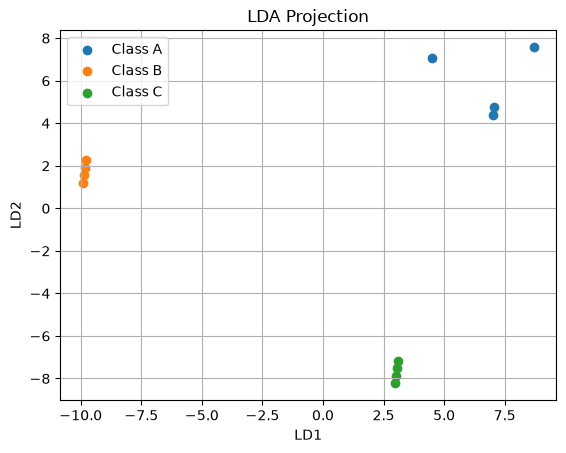

In [34]:
import matplotlib.pyplot as plt

for class_name in ["A", "B", "C"]:
    mask = y3 == class_name

    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        label=f"Class {class_name}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection")
plt.legend()
plt.grid(True)
plt.show()

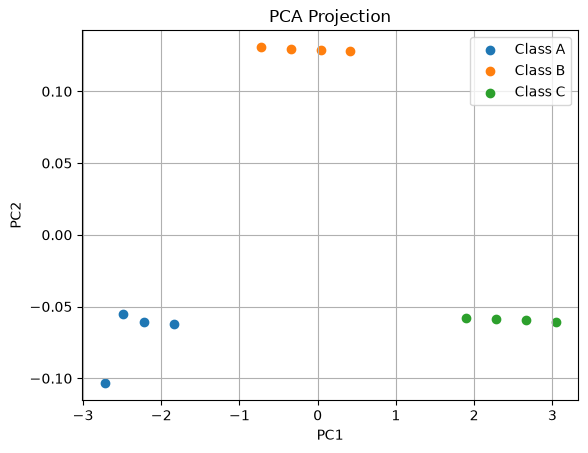

In [37]:
for class_name in ["A", "B", "C"]:
    mask = y3 == class_name

    plt.scatter(
        X_pca_2[mask, 0],
        X_pca_2[mask, 1],
        label=f"Class {class_name}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.legend()
plt.grid(True)
plt.show()